# <span style='color:purple'> PROJECT: HOUSE PRICE PREDICTION USING Linear REGRESSION

<span style='color:red'> <b>There are 14 variables in dataset:</b>
<ol>
<li> <span style='color:green'> CRIM -->  <span style='color:lightgreen'>per Capital crime rate per town.
<li>  <span style='color:green'>ZN -->  <span style='color:lightgreen'>proportion of residential land zoned for lots of 25,000 sq.ft.
<li>  <span style='color:green'>INDUS --> <span style='color:lightgreen'> proportion of non-retail business acres per town.
<li>  <span style='color:green'>CHAS --> <span style='color:lightgreen'> Charles River dummy variable (1 if tract bounds river , 0 otherwise).
<li>  <span style='color:green'>NOX --> <span style='color:lightgreen'> nitric oxides concentration(parts per 10 million).
<li>  <span style='color:green'>RM -->  <span style='color:lightgreen'>average number of rooms per dwelling
<li>  <span style='color:green'>AGE --> <span style='color:lightgreen'> propertion of owner-occupied units built prior to 1940.
<li>  <span style='color:green'>DIS --> <span style='color:lightgreen'> weighted distances to five Boston employment centres. 
<li>  <span style='color:green'>RAD -->  <span style='color:lightgreen'>index of accessibility to radial highways.
<li>  <span style='color:green'>TAX -->  <span style='color:lightgreen'>full-value property-tax rate per $10,000
<li>  <span style='color:green'>PTRATIO --> <span style='color:lightgreen'> pupil-teacher ration by town
<li>  <span style='color:green'>B --> <span style='color:lightgreen'> 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
<li>  <span style='color:green'>LSTAT --> <span style='color:lightgreen'> % lower status of the population
<li>  <span style='color:green'>MEDV --> <span style='color:lightgreen'> Median value of owner-occupied homes in $1000's

In [3]:
# importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings 
warnings.filterwarnings('ignore')

In [4]:
#  Load dataset
df = pd.read_csv("D:\\data_science_repo\\House_Price_Prediction\\Boston.csv")

In [5]:
# Display the first five rows of the dataframe
df.head()

,CRIM,ZN,INDUS,CHAS,NX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [6]:
# Get the information of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NX       506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [7]:
# Get the summary statistics
df.describe()

,CRIM,ZN,INDUS,CHAS,NX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [8]:
# Get the column names
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='str')

In [9]:
# Get the shape of the dataframe
df.shape

(506, 14)

# <span style='color:green'> Visulaization

### <span style='color:lightgreen'> Analyze the 'ZN' feature

In [10]:
df['ZN'].unique()

array([ 18. ,   0. ,  12.5,  75. ,  21. ,  90. ,  85. , 100. ,  25. ,
        17.5,  80. ,  28. ,  45. ,  60. ,  95. ,  82.5,  30. ,  22. ,
        20. ,  40. ,  55. ,  52.5,  70. ,  34. ,  33. ,  35. ])

In [11]:
df['ZN'].value_counts()

ZN
0.0      372
20.0      21
80.0      15
12.5      10
25.0      10
22.0      10
40.0       7
45.0       6
30.0       6
90.0       5
21.0       4
60.0       4
95.0       4
33.0       4
75.0       3
28.0       3
55.0       3
52.5       3
70.0       3
34.0       3
35.0       3
85.0       2
82.5       2
18.0       1
100.0      1
17.5       1
Name: count, dtype: int64

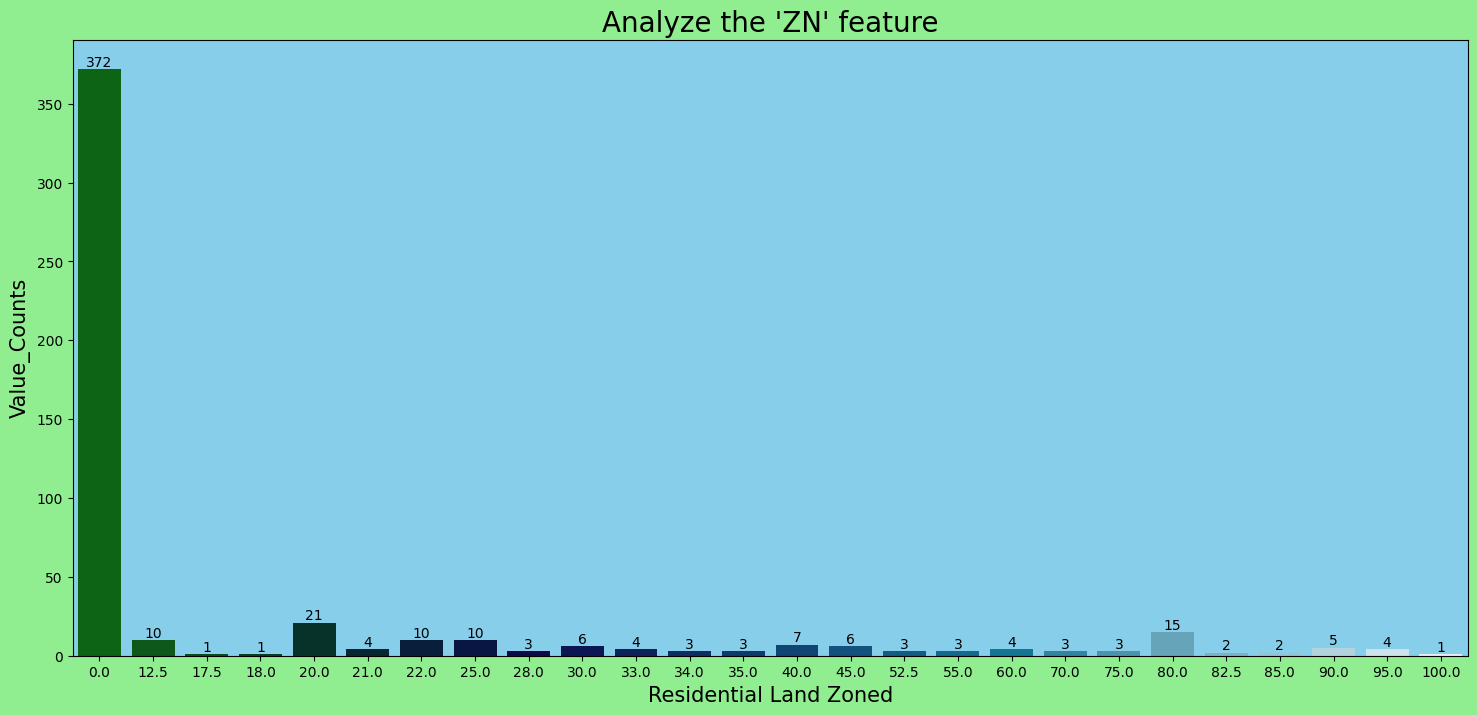

In [12]:
plt.figure(figsize=(18,8), facecolor='lightgreen')
ax = sns.countplot(data=df, x='ZN', palette='ocean')
for bars in ax.containers:
    ax.bar_label(bars)
    ax.set_facecolor('skyblue')
plt.title("Analyze the 'ZN' feature", fontsize=20)
plt.xlabel("Residential Land Zoned", fontsize=15)
plt.ylabel("Value_Counts", fontsize=15)
plt.show()

<li> Most residential area have 0 ZN and followed by a near uniform distribution from 10-100%.

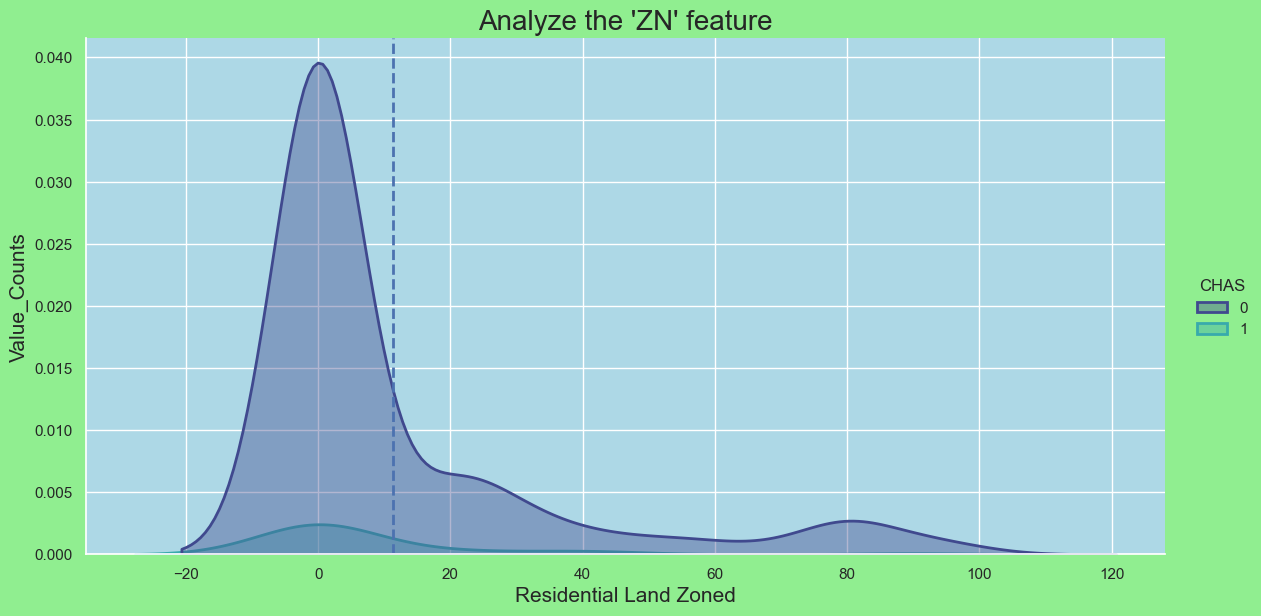

In [13]:
sns.set(rc={'axes.facecolor':'lightblue', 'figure.facecolor':'lightgreen'})
sns.displot(data=df, x='ZN', kind='kde', height=6, aspect=2, alpha=0.4, linewidth=2, hue='CHAS', fill=True, palette='mako', legend=True)
plt.axvline(df['ZN'].mean(), ls='--', linewidth=2, color='b')
plt.title("Analyze the 'ZN' feature", fontsize=20)
plt.xlabel("Residential Land Zoned", fontsize=15)
plt.ylabel("Value_Counts", fontsize=15)
plt.show()

### <span style='color:skyblue'> Analyze the 'CHAS' feature

In [14]:
df['CHAS'].unique()

array([0, 1])

In [15]:
df['CHAS'].value_counts()

CHAS
0    471
1     35
Name: count, dtype: int64

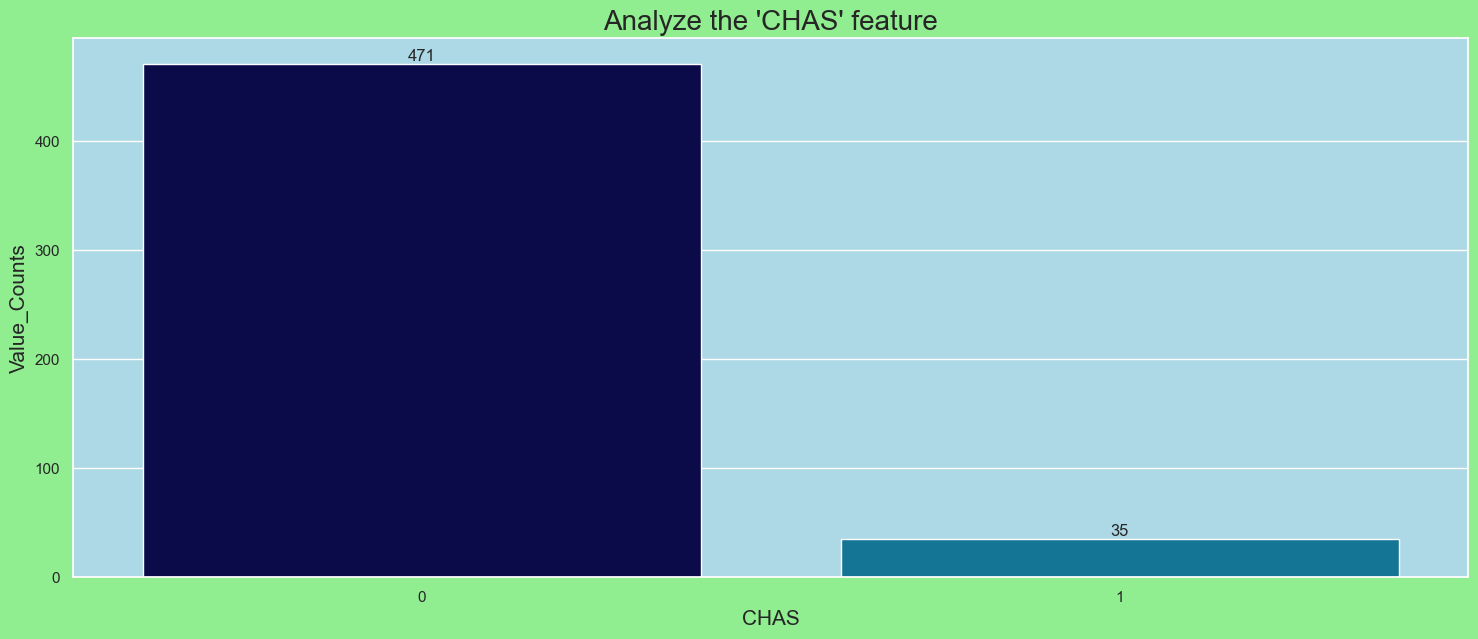

In [16]:
plt.figure(figsize=(18,7), facecolor='lightgreen')
ax = sns.countplot(data=df, x='CHAS', palette='ocean', order=df['CHAS'].value_counts(ascending=False).index)
for bars in ax.containers:
    ax.bar_label(bars)
    ax.set_facecolor('lightblue')
plt.title("Analyze the 'CHAS' feature", fontsize=20)
plt.xlabel("CHAS", fontsize=15)
plt.ylabel("Value_Counts", fontsize=15)
plt.show()

### Observation:
<li> The houses with tract bounds river are very less.
<li> The houses without tract bounds river are greater.
<li> It means the mostly houses didn't have tract bounds river

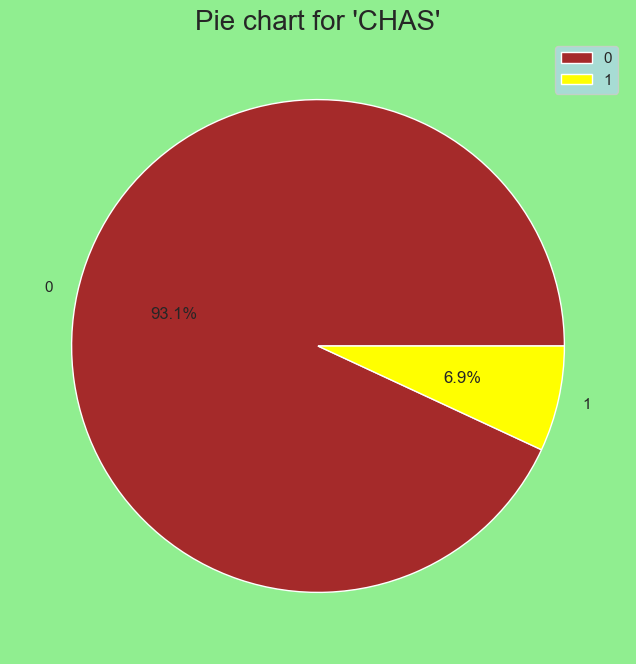

In [17]:
# Pie chart
plt.figure(figsize=(8,8), facecolor='lightgreen')
position_count = df['CHAS'].value_counts()
ax = plt.pie(position_count, labels=position_count.index, autopct="%1.1f%%", colors=['brown','yellow'])
plt.legend()
plt.title("Pie chart for 'CHAS'", fontsize=20)
plt.show()

### Observation:
<li> The value_count in terms of prcentage of 0 is greater which is 93.1%.
<li> The value_count in terms of prcentage of 1 is lesser which is 6.9%.

### <span style='color:skyblue'> Analyze the 'RAD' feature

In [18]:
df['RAD'].unique()

array([ 1,  2,  3,  5,  4,  8,  6,  7, 24])

In [19]:
df['RAD'].value_counts()

RAD
24    132
5     115
4     110
3      38
6      26
2      24
8      24
1      20
7      17
Name: count, dtype: int64

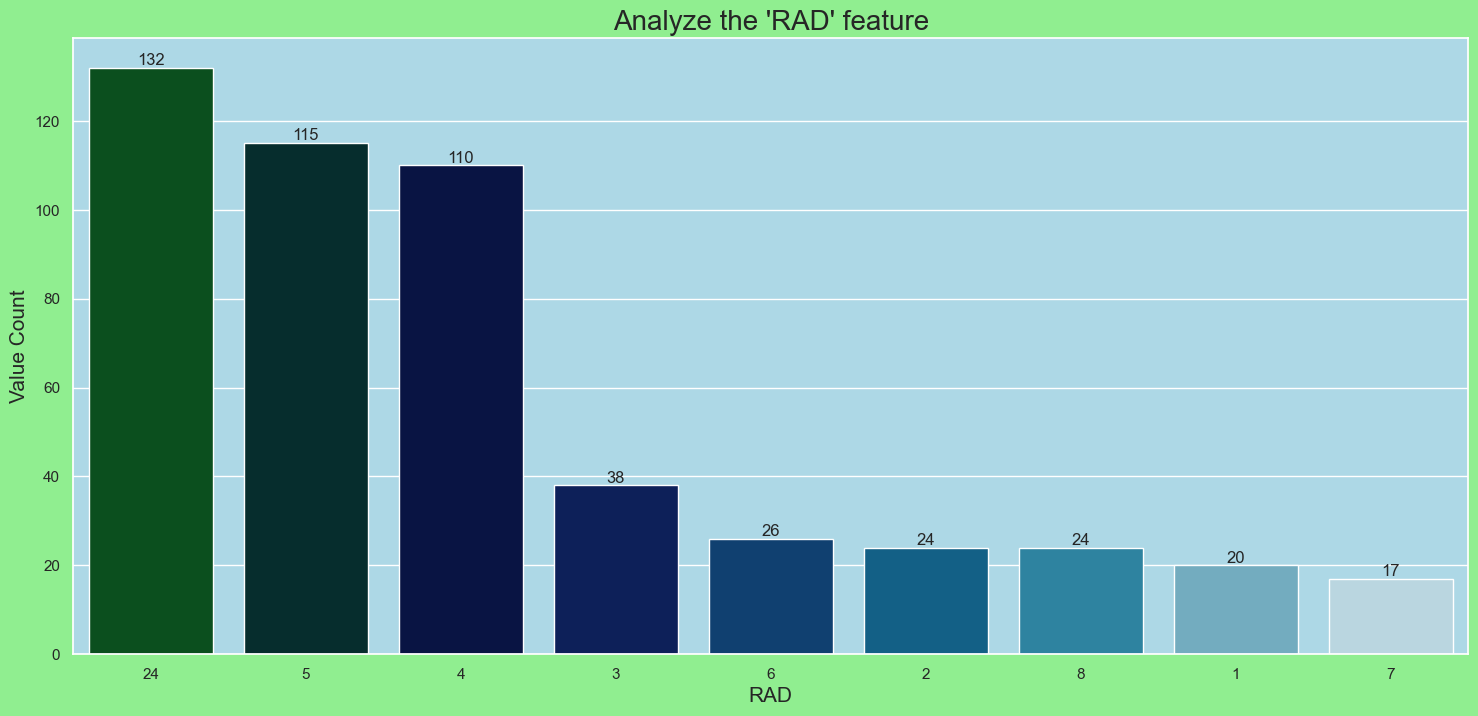

In [20]:
plt.figure(figsize=(18,8), facecolor='lightgreen')
ax = sns.countplot(data=df, x='RAD', palette='ocean', order=df['RAD'].value_counts(ascending=False).index)
for bars in ax.containers:
    ax.bar_label(bars)
    ax.set_facecolor('lightblue')
plt.title("Analyze the 'RAD' feature", fontsize=20)
plt.xlabel("RAD", fontsize=15)
plt.ylabel("Value Count", fontsize=15)
plt.show()

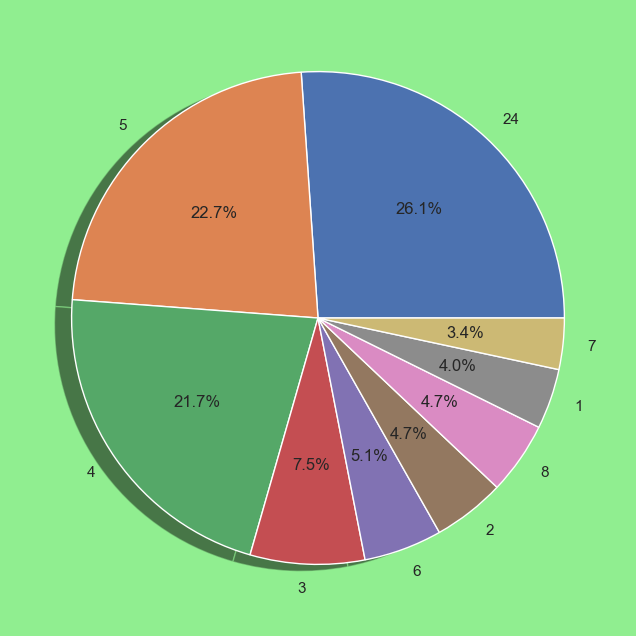

In [21]:
#pie chart
position_count = df['RAD'].value_counts()
plt.figure(figsize=(8,8), facecolor='lightgreen')
plt.pie(position_count, labels=position_count.index, autopct="%1.1f%%",shadow={'ox': -0.05, 'edgecolor': 'lightgreen', 'shade': 1})
plt.show()

### <span style='color:skyblue'> Analyze the 'TAX' feature

In [22]:
df['TAX'].value_counts()

TAX
666.0    132
307.0     40
403.0     30
437.0     15
304.0     14
        ... 
241.0      1
422.0      1
351.0      1
280.0      1
187.0      1
Name: count, Length: 66, dtype: int64

In [23]:
df['TAX'].unique()

array([296., 242., 222., 311., 307., 279., 252., 233., 243., 469., 226.,
       313., 256., 284., 216., 337., 345., 305., 398., 281., 247., 270.,
       276., 384., 432., 188., 437., 403., 193., 265., 255., 329., 402.,
       348., 224., 277., 300., 330., 315., 244., 264., 223., 254., 198.,
       285., 241., 293., 245., 289., 358., 304., 287., 430., 422., 370.,
       352., 351., 280., 335., 411., 187., 334., 666., 711., 391., 273.])

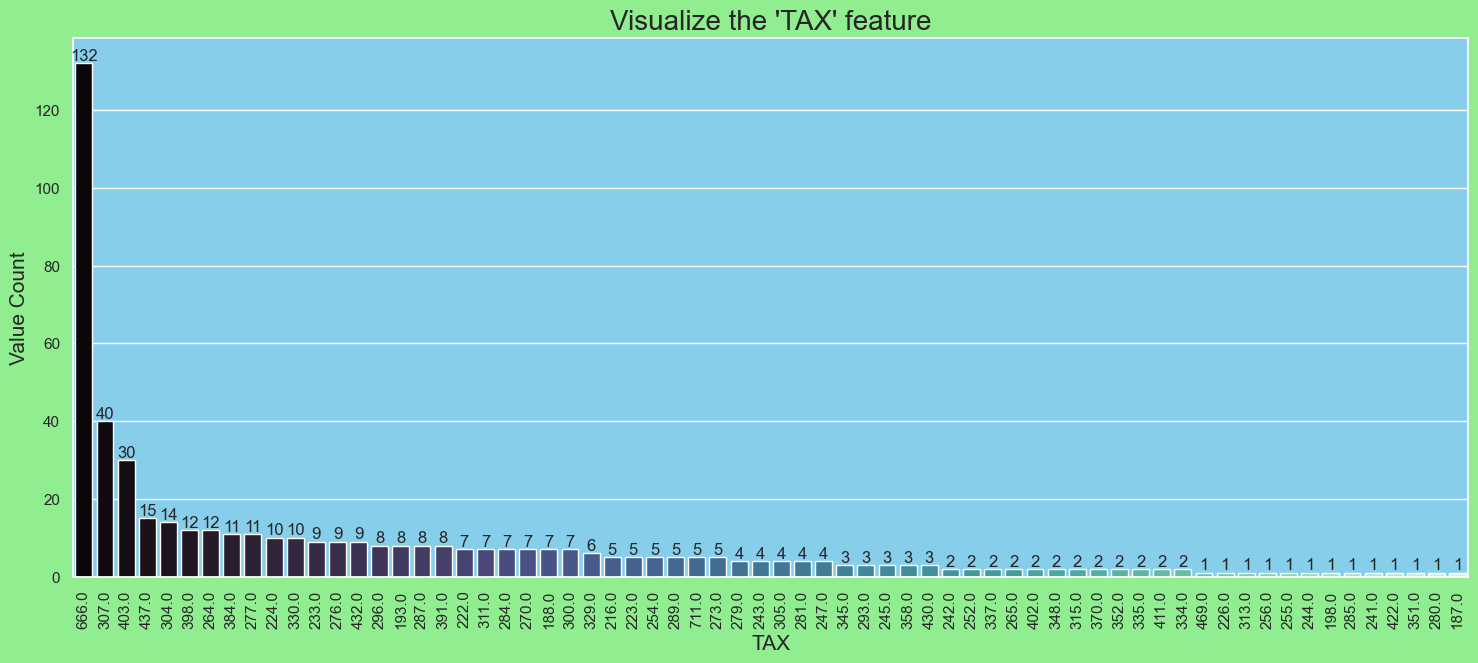

In [24]:
plt.figure(figsize=(18,7), facecolor='lightgreen')
ax = sns.countplot(data=df, x='TAX', palette='mako', order=df['TAX'].value_counts(ascending=False).index)
for bars in ax.containers:
    ax.bar_label(bars)
    ax.set_facecolor('skyblue')
plt.title("Visualize the 'TAX' feature", fontsize=20)
plt.xlabel("TAX", fontsize=15)
plt.ylabel("Value Count", fontsize=15)
plt.xticks(rotation=90)
plt.show()

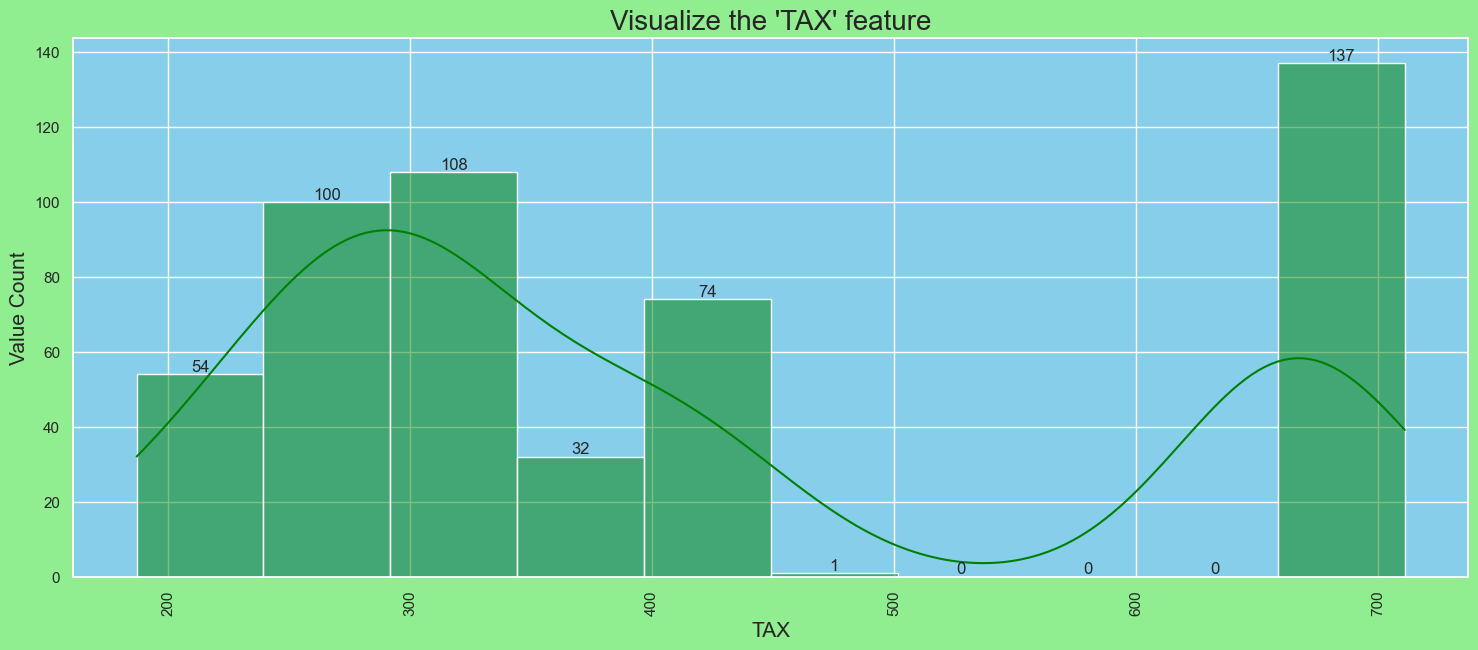

In [25]:
plt.figure(figsize=(18,7), facecolor='lightgreen')
ax = sns.histplot(data=df, x='TAX', color='green', kde=True)
for bars in ax.containers:
    ax.bar_label(bars)
    ax.set_facecolor('skyblue')
plt.title("Visualize the 'TAX' feature", fontsize=20)
plt.xlabel("TAX", fontsize=15)
plt.ylabel("Value Count", fontsize=15)
plt.xticks(rotation=90)
plt.show()

### <span style='color:skyblue'>Analyze the 'MEDV' feature

In [26]:
df['MEDV'].unique()

array([24. , 21.6, 34.7, 33.4, 36.2, 28.7, 22.9, 27.1, 16.5, 18.9, 15. ,
       21.7, 20.4, 18.2, 19.9, 23.1, 17.5, 20.2, 13.6, 19.6, 15.2, 14.5,
       15.6, 13.9, 16.6, 14.8, 18.4, 21. , 12.7, 13.2, 13.1, 13.5, 20. ,
       24.7, 30.8, 34.9, 26.6, 25.3, 21.2, 19.3, 14.4, 19.4, 19.7, 20.5,
       25. , 23.4, 35.4, 31.6, 23.3, 18.7, 16. , 22.2, 33. , 23.5, 22. ,
       17.4, 20.9, 24.2, 22.8, 24.1, 21.4, 20.8, 20.3, 28. , 23.9, 24.8,
       22.5, 23.6, 22.6, 20.6, 28.4, 38.7, 43.8, 33.2, 27.5, 26.5, 18.6,
       20.1, 19.5, 19.8, 18.8, 18.5, 18.3, 19.2, 17.3, 15.7, 16.2, 18. ,
       14.3, 23. , 18.1, 17.1, 13.3, 17.8, 14. , 13.4, 11.8, 13.8, 14.6,
       15.4, 21.5, 15.3, 17. , 41.3, 24.3, 27. , 50. , 22.7, 23.8, 22.3,
       19.1, 29.4, 23.2, 24.6, 29.9, 37.2, 39.8, 37.9, 32.5, 26.4, 29.6,
       32. , 29.8, 37. , 30.5, 36.4, 31.1, 29.1, 33.3, 30.3, 34.6, 32.9,
       42.3, 48.5, 24.4, 22.4, 28.1, 23.7, 26.7, 30.1, 44.8, 37.6, 46.7,
       31.5, 31.7, 41.7, 48.3, 29. , 25.1, 17.6, 24

In [27]:
df['MEDV'].value_counts()

MEDV
50.0    16
25.0     8
21.7     7
23.1     7
22.0     7
        ..
13.0     1
16.4     1
17.7     1
12.0     1
8.1      1
Name: count, Length: 229, dtype: int64

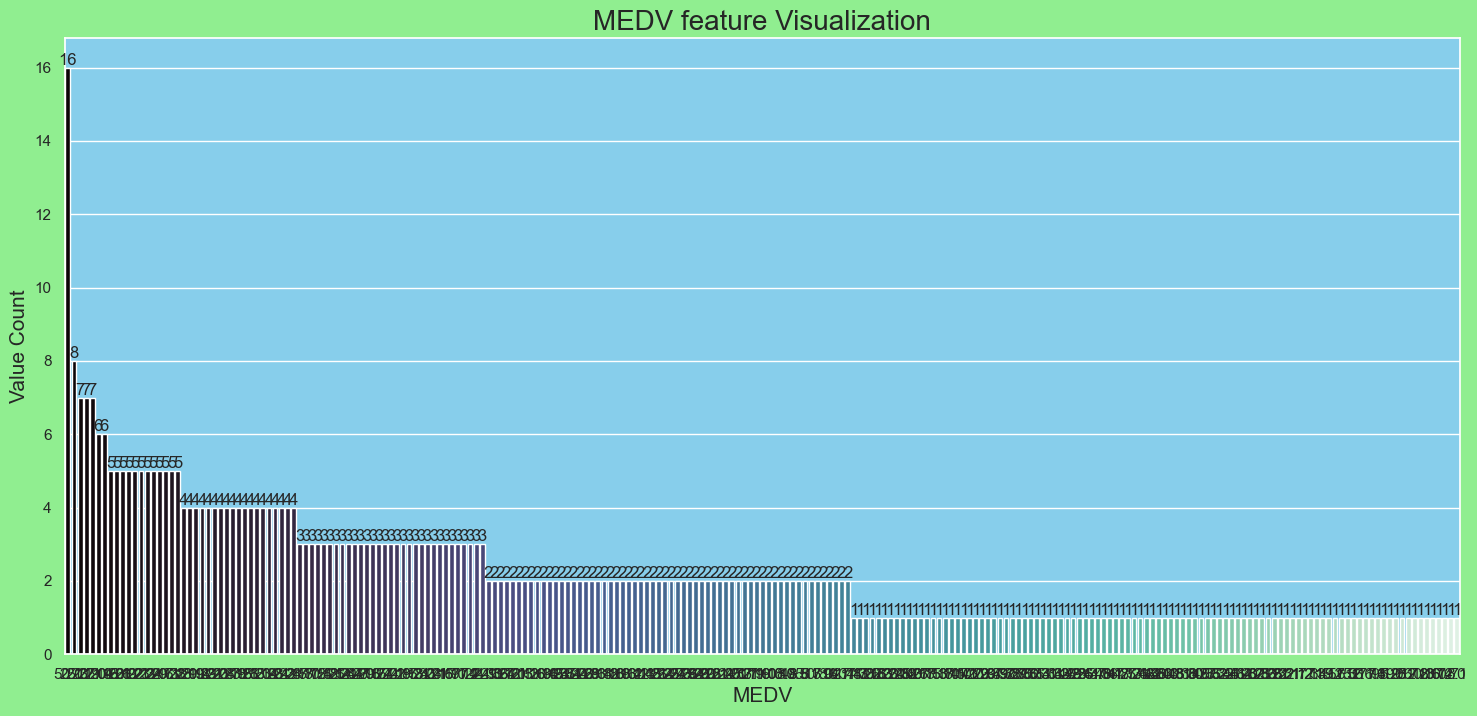

In [28]:
plt.figure(figsize=(18,8), facecolor='lightgreen')
ax = sns.countplot(data=df, x='MEDV', palette='mako', order=df['MEDV'].value_counts(ascending=False).index)
for bars in ax.containers:
    ax.bar_label(bars)
    ax.set_facecolor('skyblue')
plt.title("MEDV feature Visualization", fontsize=20)
plt.xlabel("MEDV", fontsize=15)
plt.ylabel("Value Count", fontsize=15)
plt.show()

In [29]:
df.head(1)

,CRIM,ZN,INDUS,CHAS,NX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.09,1,296.0,15.3,396.9,4.98,24.0


### <span style='color:skyblue'> Define y(dependent or label or target variable) and X(independent or feature or attribute variable)

In [30]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']

In [31]:
X.shape

(506, 13)

In [32]:
X

,CRIM,ZN,INDUS,CHAS,NX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48


In [33]:
y.shape

(506,)

In [34]:
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: MEDV, Length: 506, dtype: float64

In [35]:
# Get X variable standarized

from sklearn.preprocessing import MinMaxScaler

In [36]:
mm = MinMaxScaler()

In [37]:
X = mm.fit_transform(X)

In [38]:
X

array([[0.00000000e+00, 1.80000000e-01, 6.78152493e-02, ...,
        2.87234043e-01, 1.00000000e+00, 8.96799117e-02],
       [2.35922539e-04, 0.00000000e+00, 2.42302053e-01, ...,
        5.53191489e-01, 1.00000000e+00, 2.04470199e-01],
       [2.35697744e-04, 0.00000000e+00, 2.42302053e-01, ...,
        5.53191489e-01, 9.89737254e-01, 6.34657837e-02],
       ...,
       [6.11892474e-04, 0.00000000e+00, 4.20454545e-01, ...,
        8.93617021e-01, 1.00000000e+00, 1.07891832e-01],
       [1.16072990e-03, 0.00000000e+00, 4.20454545e-01, ...,
        8.93617021e-01, 9.91300620e-01, 1.31070640e-01],
       [4.61841693e-04, 0.00000000e+00, 4.20454545e-01, ...,
        8.93617021e-01, 1.00000000e+00, 1.69701987e-01]], shape=(506, 13))

In [39]:
# Train test split

from sklearn.model_selection import train_test_split

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2529)

In [41]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((354, 13), (152, 13), (354,), (152,))

In [42]:
# Get model train
from sklearn.linear_model import LinearRegression

In [43]:
LR = LinearRegression()

In [44]:
LR.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [45]:
LR_pred = LR.predict(X_test)

In [46]:
# get model prediction
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [47]:
mean_squared_error(y_test, LR_pred)

20.71801287783854

In [48]:
mean_absolute_error(y_test, LR_pred)

3.1550309276024917

In [49]:
r2_score(y_test, LR_pred)

0.6551914852365519

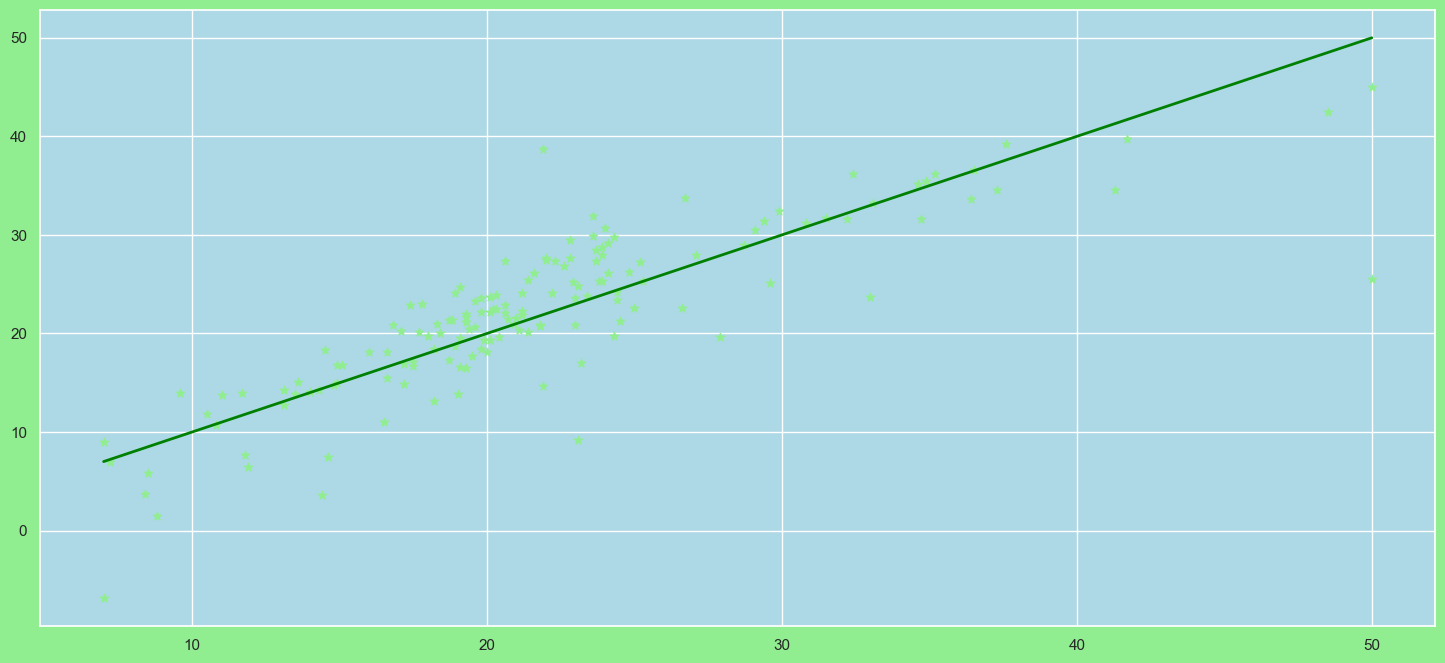

In [50]:
# Visualization of actual vs predicted result
plt.figure(figsize=(18,8), facecolor='lightgreen')
plt.scatter(y_test, LR_pred, color='lightgreen', marker='*')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='green', lw=2)
plt.show()

In [51]:
# Get future Prediction
X_new = df.sample()

In [52]:
X_new

,CRIM,ZN,INDUS,CHAS,NX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
145,2.37934,0.0,19.58,0,0.871,6.13,100.0,1.4191,5,403.0,14.7,172.91,27.8,13.8


In [53]:
X_new.shape

(1, 14)

In [54]:
X_new = X_new.drop('MEDV', axis=1)

In [55]:
X_new

,CRIM,ZN,INDUS,CHAS,NX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
145,2.37934,0.0,19.58,0,0.871,6.13,100.0,1.4191,5,403.0,14.7,172.91,27.8


In [56]:
X_new.shape

(1, 13)

In [57]:
X_new = mm.fit_transform(X_new)

In [58]:
LR_pred_new = LR.predict(X_new)

In [59]:
LR_pred_new

array([25.6750862])

In [60]:
df.head(263)

,CRIM,ZN,INDUS,CHAS,NX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,0.66351,20.0,3.97,0,0.647,7.333,100.0,1.8946,5,264.0,13.0,383.29,7.79,36.0
259,0.65665,20.0,3.97,0,0.647,6.842,100.0,2.0107,5,264.0,13.0,391.93,6.90,30.1
260,0.54011,20.0,3.97,0,0.647,7.203,81.8,2.1121,5,264.0,13.0,392.80,9.59,33.8
261,0.53412,20.0,3.97,0,0.647,7.520,89.4,2.1398,5,264.0,13.0,388.37,7.26,43.1


In [61]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [62]:
r2_score(y_test, dt_pred)

0.6615867468365657

In [63]:
from sklearn.ensemble import RandomForestRegressor
dt = RandomForestRegressor(n_estimators=200)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

r2_score(y_test, dt_pred)

0.7991332762485894

In [64]:
from sklearn.ensemble import GradientBoostingRegressor
dt = GradientBoostingRegressor(n_estimators=40)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

r2_score(y_test, dt_pred)

0.8064870583697049

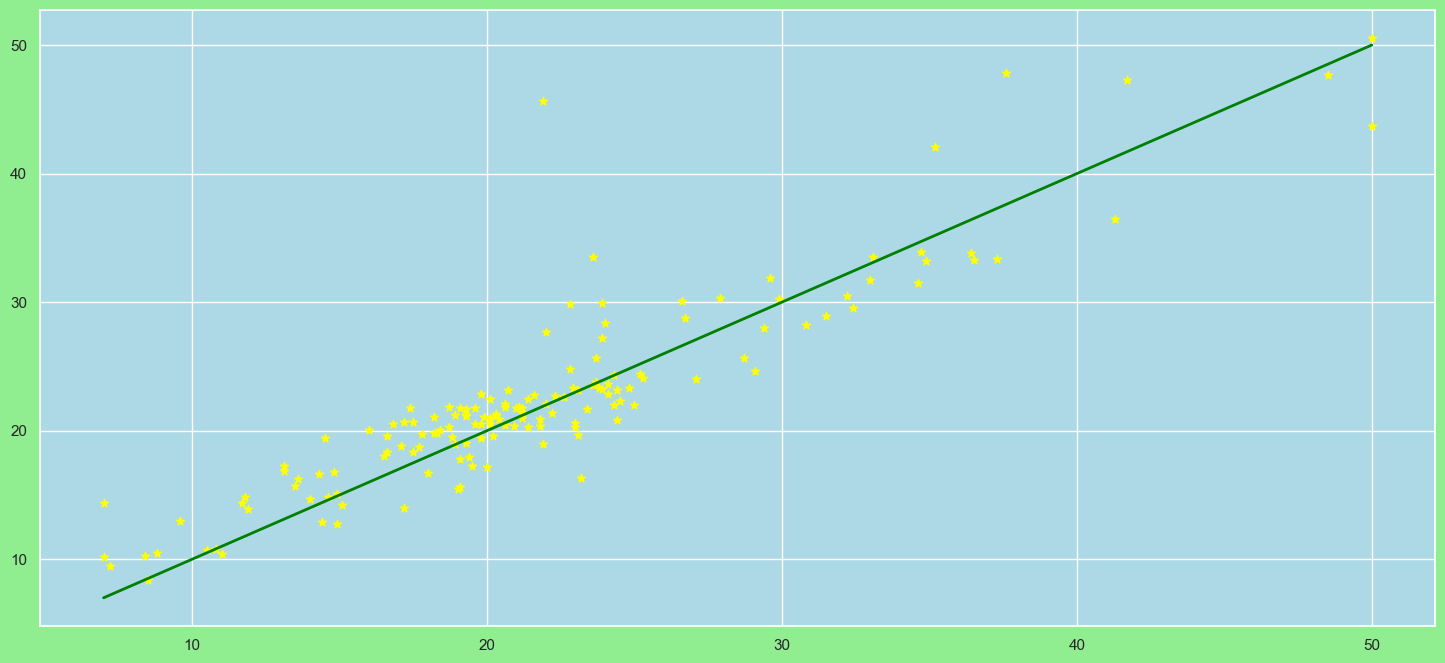

In [65]:
# Visualization of actual vs predicted result
plt.figure(figsize=(18,8), facecolor='lightgreen')
plt.scatter(y_test, dt_pred, color='yellow', marker='*')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='green', lw=2)
plt.show()

In [67]:
import pickle 
pickle.dump(dt,open('model.pkl','wb'))